# ViT-Base FER2013 — Kaggle P100 Optimised

**Hardware target:** Kaggle free tier (P100 16 GB VRAM, 30 GB RAM, 4 CPU cores)  
**Strategy:** Cache tiny 48×48 grayscale tensors in RAM (~250 MB), resize + augment on GPU  

### Required Kaggle Settings (Session Options, right sidebar)
| Setting | Value |
|---|---|
| Accelerator | **GPU → P100** |
| Internet | **ON** (keras_hub needs to download ViT weights) |
| Persistence | **Files** (keeps checkpoints in /kaggle/working) |

### Expected dataset layout
```
/kaggle/input/<your-dataset-slug>/
    fer2013_data/
        train/<emotion>/*.jpg
        test/<emotion>/*.jpg
```

## Cell 1 — Install dependencies

In [10]:

import os
import numpy as np
import tensorflow as tf
import keras_hub

from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Cell 2 — Imports

In [11]:
# ── Core imports ──────────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential, Model
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import *
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 3 — Mixed precision + configuration

> ✏️ **Edit `DATASET_SLUG`** to match your Kaggle dataset name (the part after your username in the dataset URL).

In [12]:
# =========================================================
# GPU + MIXED PRECISION
# =========================================================

# Uses float16 where possible:
# - lower VRAM
# - faster training
# - essential for ViT efficiency

tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Prevent TensorFlow from allocating all VRAM immediately
gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("GPU memory growth enabled.")

    except RuntimeError as e:
        print(e)

print("Available GPUs:", gpus)

GPU memory growth enabled.
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
BASE_DIR = f"/kaggle/input/datasets/msambare/fer2013"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
# =========================================================
# CONFIG
# =========================================================

IMG_SIZE   = (192, 192)   # Better speed/accuracy balance than 224
BATCH_SIZE = 32
NUM_CLASSES = 7

AUTOTUNE = tf.data.AUTOTUNE

EPOCHS_STAGE1 = 8
EPOCHS_STAGE2 = 20

## Cell 4 — Load dataset at native 48×48 grayscale

Loading at native size keeps the cache footprint at **~250 MB** instead of ~17 GB.

In [14]:
# =========================================================
# TRAIN / VALIDATION DATASETS
# =========================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(48, 48),   # Load native size first
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(48, 48),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='int'
)

# =========================================================
# TEST DATASET
# =========================================================

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(48, 48),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='int',
    shuffle=False
)

class_names = train_ds.class_names

print("\nClasses:", class_names)
print("Number of Classes:", len(class_names))

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of Classes: 7


## Cell 5 — tf.data pipeline

`cache()` here stores ~250 MB of tiny 48×48 tensors in Kaggle's 30 GB RAM — completely safe.  
Augmentation is **not** in the pipeline; it lives inside a GPU Keras model (Cell 6).

## Cell 6 — Class weights

FER-2013 is heavily imbalanced (disgust has ~5× fewer samples than happy).  
`compute_class_weight('balanced')` compensates automatically.

In [15]:
# =========================================================
# CLASS WEIGHTS
# =========================================================

y_train = []

for _, labels in train_ds:
    y_train.extend(labels.numpy())

y_train = np.array(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("\nClass Weights:")
print(class_weights)


Class Weights:
{0: np.float64(1.0196217703986505), 1: np.float64(9.03896103896104), 2: np.float64(0.998825831702544), 3: np.float64(0.5644491410877098), 4: np.float64(0.8275265717888669), 5: np.float64(0.8558014755197854), 6: np.float64(1.3177280550774526)}


## Cell 7 — GPU preprocessor + augmentation model

All ops (resize, grayscale→RGB, augmentation) run as **fused GPU kernels** — zero CPU cost.  
Two versions are built: one with augmentation (train) and one without (val/test).

In [16]:
# =========================================================
# GPU PREPROCESSING + AUGMENTATION
# =========================================================

def build_preprocessor(augment=False):

    inputs = layers.Input(shape=(48, 48, 1))

    # Resize
    x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1])(inputs)

    # Grayscale → RGB
    x = layers.Lambda(
        lambda t: tf.image.grayscale_to_rgb(t)
    )(x)

    # Normalize
    x = layers.Rescaling(1./255)(x)

    if augment:

        x = layers.RandomFlip("horizontal")(x)

        x = layers.RandomRotation(
            0.03,
            fill_mode='nearest'
        )(x)

        x = layers.RandomZoom(
            0.05,
            fill_mode='nearest'
        )(x)

        x = layers.RandomTranslation(
            0.05,
            0.05,
            fill_mode='nearest'
        )(x)

    return tf.keras.Model(inputs, x)

train_preprocessor = build_preprocessor(augment=True)
val_preprocessor   = build_preprocessor(augment=False)

In [17]:
# =========================================================
# APPLY GPU PREPROCESSING
# =========================================================

train_ds = (
    train_ds
    .cache()
    .shuffle(8000)
    .map(
        lambda x, y: (
            train_preprocessor(x, training=True),
            y
        ),
        num_parallel_calls=AUTOTUNE
    )
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .map(
        lambda x, y: (
            val_preprocessor(x, training=False),
            y
        ),
        num_parallel_calls=AUTOTUNE
    )
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .cache()
    .map(
        lambda x, y: (
            val_preprocessor(x, training=False),
            y
        ),
        num_parallel_calls=AUTOTUNE
    )
    .prefetch(AUTOTUNE)
)

print("Dataset pipeline ready.")

Dataset pipeline ready.


## Cell 8 — Load ViT-Base backbone from Keras Hub

Downloads ~330 MB of ImageNet pretrained weights on first run (requires Internet ON).  
Subsequent runs use the Kaggle cache automatically.

In [19]:
# =========================================================
# LOAD ViT MODEL
# =========================================================

model = keras_hub.models.ImageClassifier.from_preset(
    'hf://keras/vit_base_patch16_224_imagenet',
    num_classes=NUM_CLASSES
)

print(model.summary())

Preprocessor: "vi_t_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vi_t_image_converter (ViTImageConverter)                      │                   Image size: (224, 224) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vi_t_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer)                           │ (None, 224, 224, 3)                │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vi_t_backbone (ViTBackbone)                   │ (None, 197, 768)                   │          85,798,656 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ get_item (GetItem)                            │ (None, 768)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ output_dropout (Dropout)                      │ (None, 768)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 7)                          │               5,383 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 85,804,039 (327.32 MB)

 Trainable params: 85,804,039 (327.32 MB)

 Non-trainable params: 0 (0.00 B)

None


## Cell 9 — Stage 1: Warm-Up (frozen backbone, train head only)

Backbone is frozen so ImageNet weights are protected from the large initial gradients.  
Only the new classification head (~3k parameters) is updated.  
Expected: ~2–3 minutes total on P100.

In [20]:
# =========================================================
# STAGE 1 — FROZEN BACKBONE
# =========================================================

model.backbone.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=['accuracy']
)

callbacks_stage1 = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("\n===================================")
print("STAGE 1 — Training Head Only")
print("===================================")

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=callbacks_stage1
)


STAGE 1 — Training Head Only
Epoch 1/8
  1/718 ━━━━━━━━━━━━━━━━━━━━ 4:44:04 24s/step - accuracy: 0.0938 - loss: 2.8407

I0000 00:00:1779956824.987680    1324 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


718/718 ━━━━━━━━━━━━━━━━━━━━ 211s 261ms/step - accuracy: 0.1284 - loss: 1.9952 - val_accuracy: 0.1946 - val_loss: 1.9053 - learning_rate: 0.0010
Epoch 2/8
718/718 ━━━━━━━━━━━━━━━━━━━━ 174s 241ms/step - accuracy: 0.1328 - loss: 1.9872 - val_accuracy: 0.2372 - val_loss: 1.8666 - learning_rate: 0.0010
Epoch 3/8
718/718 ━━━━━━━━━━━━━━━━━━━━ 173s 239ms/step - accuracy: 0.1373 - loss: 1.9787 - val_accuracy: 0.0904 - val_loss: 2.0064 - learning_rate: 0.0010
Epoch 4/8
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.1338 - loss: 1.9725
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
718/718 ━━━━━━━━━━━━━━━━━━━━ 173s 240ms/step - accuracy: 0.1382 - loss: 1.9752 - val_accuracy: 0.0798 - val_loss: 2.0389 - learning_rate: 0.0010
Epoch 5/8
718/718 ━━━━━━━━━━━━━━━━━━━━ 172s 238ms/step - accuracy: 0.1487 - loss: 1.9473 - val_accuracy: 0.2075 - val_loss: 1.8928 - learning_rate: 5.0000e-04
Epoch 6/8
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.1499 - loss

## Cell 10 — Stage 2: Deep Fine-Tuning (all 86 M parameters)

- **AdamW** with `weight_decay=1e-4` — critical for ViTs to prevent over-fitting  
- **lr = 5e-5** — 20× smaller than Stage 1 to avoid destroying pretrained features  
- `ReduceLROnPlateau` will halve the LR automatically if val_loss plateaus  
- `EarlyStopping` with patience=5 will stop training when val_loss stops improving  

Expected: ~90–120 s/epoch, EarlyStopping typically triggers around epoch 10–15.

In [21]:
# =========================================================
# STAGE 2 — PARTIAL FINE-TUNING
# =========================================================

model.backbone.trainable = True

# Freeze lower transformer blocks
for layer in model.backbone.layers[:-25]:
    layer.trainable = False

# Keep LayerNorm / BatchNorm stable
for layer in model.backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("\nTrainable Layers:")

trainable_count = 0

for layer in model.backbone.layers:
    if layer.trainable:
        trainable_count += 1

print(trainable_count)

# =========================================================
# RECOMPILE
# =========================================================

model.compile(

    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=['accuracy']
)

callbacks_stage2 = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_vit_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("\n===================================")
print("STAGE 2 — Fine-Tuning")
print("===================================")

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weights,
    callbacks=callbacks_stage2
)


Trainable Layers:
3

STAGE 2 — Fine-Tuning
Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.1203 - loss: 2.0093
Epoch 1: val_accuracy improved from None to 0.16530, saving model to best_vit_model.keras

Epoch 1: finished saving model to best_vit_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 485s 601ms/step - accuracy: 0.1246 - loss: 1.9736 - val_accuracy: 0.1653 - val_loss: 1.9268 - learning_rate: 1.0000e-05
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.1368 - loss: 1.9416
Epoch 2: val_accuracy did not improve from 0.16530
718/718 ━━━━━━━━━━━━━━━━━━━━ 400s 556ms/step - accuracy: 0.1359 - loss: 1.9576 - val_accuracy: 0.1585 - val_loss: 1.9296 - learning_rate: 1.0000e-05
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.1709 - loss: 1.9245
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_accuracy did not improve from 0.16530
718/718 ━━━━━━━━━━━━━━━━━━━━ 400s 556ms/step - accuracy: 0.1912 - lo

## Cell 11 — Final evaluation & save

In [22]:
# =========================================================
# FINAL EVALUATION
# =========================================================

test_loss, test_acc = model.evaluate(test_ds)

print("\nTest Accuracy:", test_acc)
print("Test Loss:", test_loss)

225/225 ━━━━━━━━━━━━━━━━━━━━ 42s 186ms/step - accuracy: 0.4291 - loss: 1.4924

Test Accuracy: 0.42908889055252075
Test Loss: 1.4923804998397827


## Cell 12 — (Optional) Plot training history

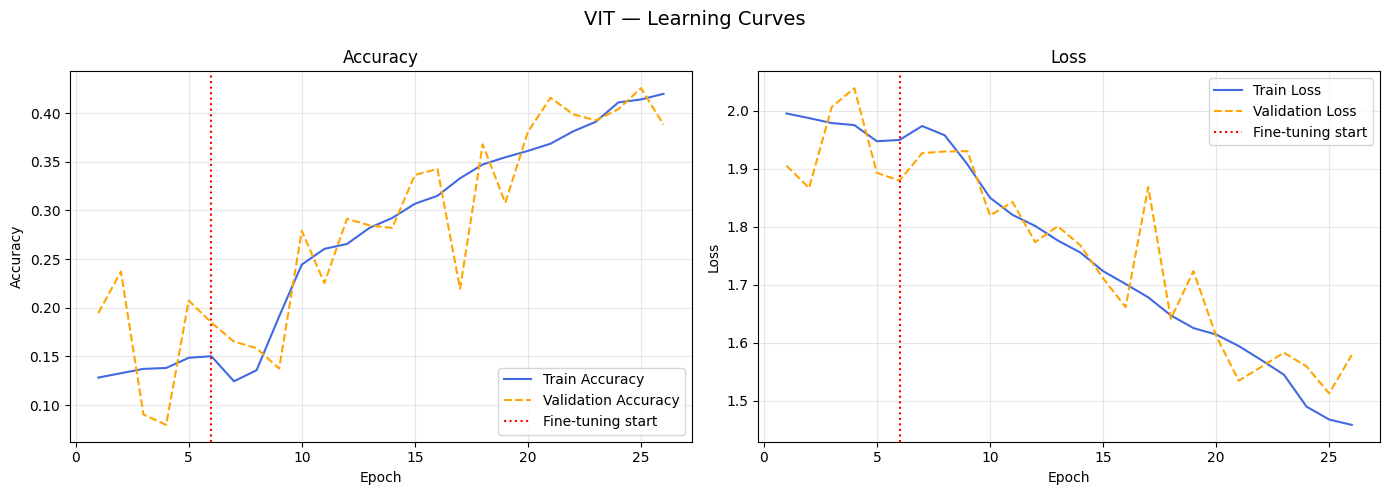

In [23]:
# ── Plot Learning Curves (both stages combined) ────────────────

def plot_learning_curves(history1, history2, title_prefix='VIT'):
    """
    Combines training history from both stages and plots
    accuracy and loss learning curves.
    """
    # Combine both stages
    acc     = history1.history['accuracy']     + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss    = history1.history['loss']         + history2.history['loss']
    val_loss= history1.history['val_loss']     + history2.history['val_loss']

    stage_boundary = len(history1.history['accuracy'])
    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title_prefix} — Learning Curves', fontsize=14)

    # Accuracy plot
    ax1.plot(epochs_range, acc,     label='Train Accuracy',      color='royalblue')
    ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linestyle='--')
    ax1.axvline(x=stage_boundary, color='red', linestyle=':', label='Fine-tuning start')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Loss plot
    ax2.plot(epochs_range, loss,     label='Train Loss',      color='royalblue')
    ax2.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linestyle='--')
    ax2.axvline(x=stage_boundary, color='red', linestyle=':', label='Fine-tuning start')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_stage1, history_stage2, 'VIT')

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('Generating predictions...')

# =========================================================
# PREDICTIONS
# =========================================================

y_pred_probs = model.predict(test_ds, verbose=1)

# Convert logits/probabilities → class indices
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# =========================================================
# TRUE LABELS
# =========================================================

# Since label_mode='int',
# labels are already integer encoded

y_true = np.concatenate([
    y.numpy() for x, y in test_ds
], axis=0)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print('\nClassification Report:\n')

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))


Generating predictions...
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 174ms/step

Classification Report:

              precision    recall  f1-score   support

       angry       0.33      0.26      0.29       958
     disgust       0.10      0.56      0.17       111
        fear       0.32      0.26      0.29      1024
       happy       0.66      0.55      0.60      1774
     neutral       0.38      0.47      0.42      1233
         sad       0.39      0.29      0.33      1247
    surprise       0.57      0.69      0.62       831

    accuracy                           0.43      7178
   macro avg       0.39      0.44      0.39      7178
weighted avg       0.45      0.43      0.43      7178



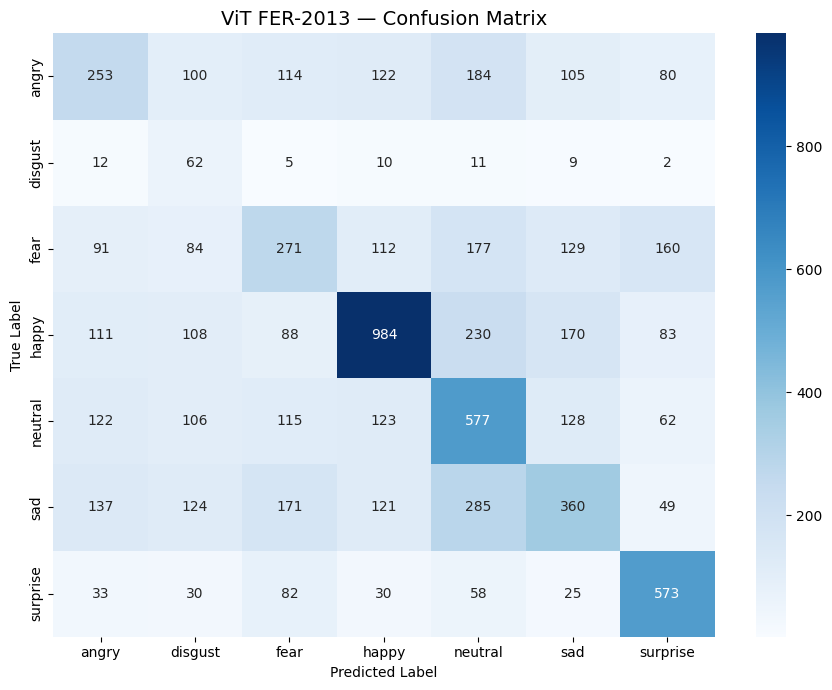

Confusion matrix displayed.


In [26]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('ViT FER-2013 — Confusion Matrix', fontsize=14)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

print('Confusion matrix displayed.')